In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Shape
(12330, 18)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   123

In [4]:
print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isnull().sum())

print("\n")
print("=" * 50)
print("Duplicate Rows")
print("=" * 50)
print(df.duplicated().sum())

print("\n")
print("=" * 50)
print("Statistical Summary")
print("=" * 50)
print(df.describe(include="all"))

Missing Values
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


Duplicate Rows
125


Statistical Summary
        Administrative  Administrative_Duration  Informational  \
count     12330.000000             12330.000000   12330.000000   
unique             NaN                      NaN            NaN   
top                NaN                      NaN            NaN   
freq               NaN                      NaN            NaN   
mean          2.315166                80.818611       0.503569   
std        

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().sum()/len(df)*100
    ).round(2)
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Administrative,0,0.0
Administrative_Duration,0,0.0
Weekend,0,0.0
VisitorType,0,0.0
TrafficType,0,0.0
Region,0,0.0
Browser,0,0.0
OperatingSystems,0,0.0
Month,0,0.0
SpecialDay,0,0.0


In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 125


In [7]:
unique_df = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique_df

,Unique Values,Data Type
Administrative,27,int64
Administrative_Duration,3335,float64
Informational,17,int64
Informational_Duration,1258,float64
ProductRelated,311,int64
ProductRelated_Duration,9551,float64
BounceRates,1872,float64
ExitRates,4777,float64
PageValues,2704,float64
SpecialDay,6,float64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


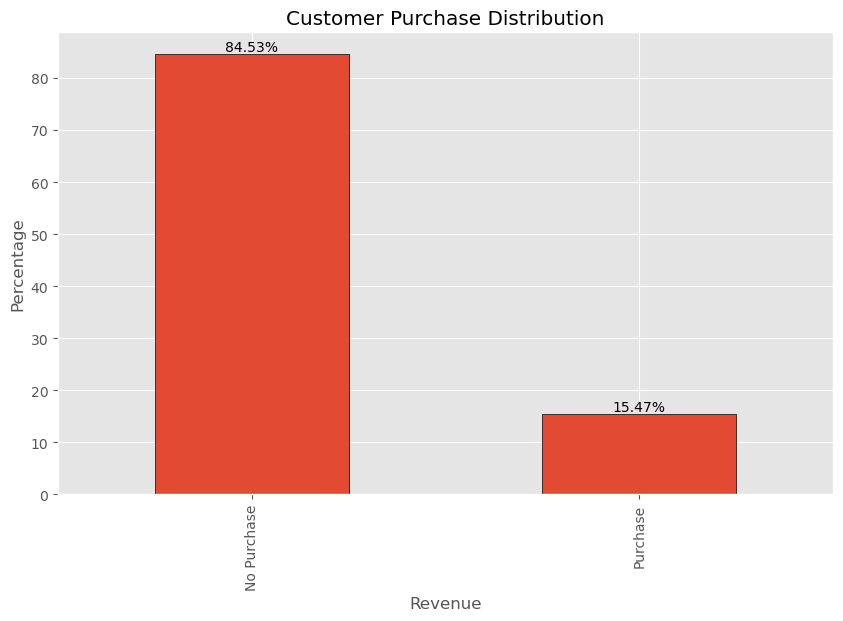

In [9]:
purchase_rate = (
    df["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .rename({False:"No Purchase",
             True:"Purchase"})
)

ax = purchase_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Customer Purchase Distribution")
plt.ylabel("Percentage")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

In [10]:
continuous_features = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

count_features = [
    "Administrative",
    "Informational",
    "ProductRelated"
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

In [11]:
skewness = (
    df[continuous_features + count_features]
    .skew()
    .sort_values(ascending=False)
)

skewness.to_frame("Skewness")

,Skewness
Informational_Duration,7.579185
ProductRelated_Duration,7.263228
PageValues,6.382964
Administrative_Duration,5.615719
ProductRelated,4.341516
Informational,4.036464
SpecialDay,3.302667
BounceRates,2.947855
ExitRates,2.148789
Administrative,1.960357


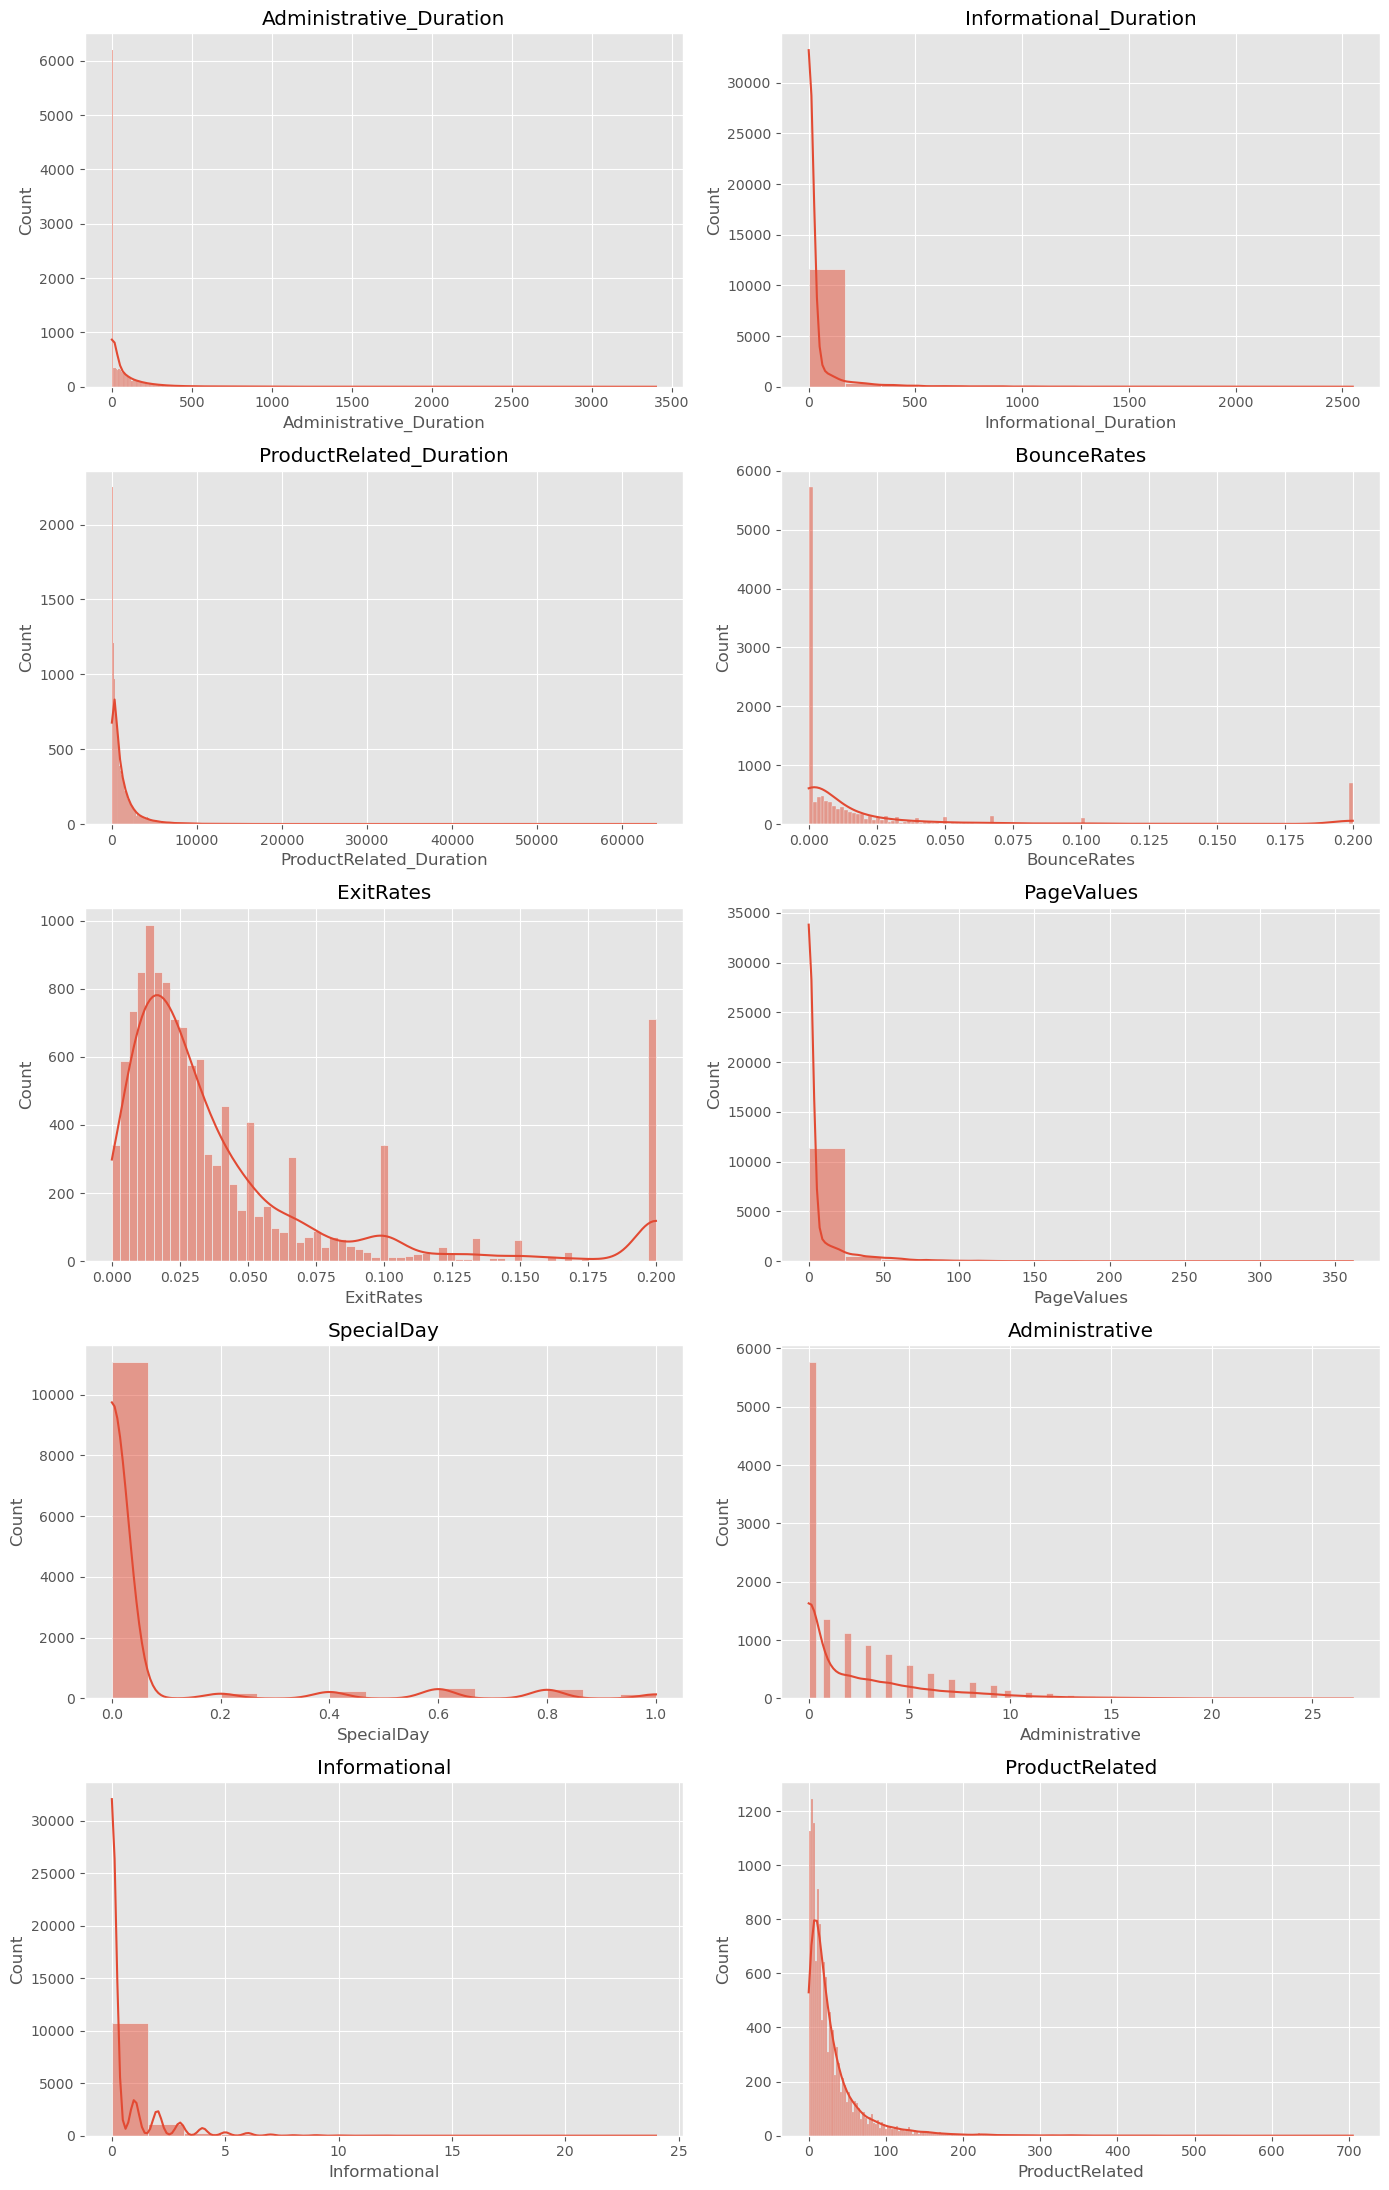

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

num_features = continuous_features + count_features

for i, col in enumerate(num_features):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

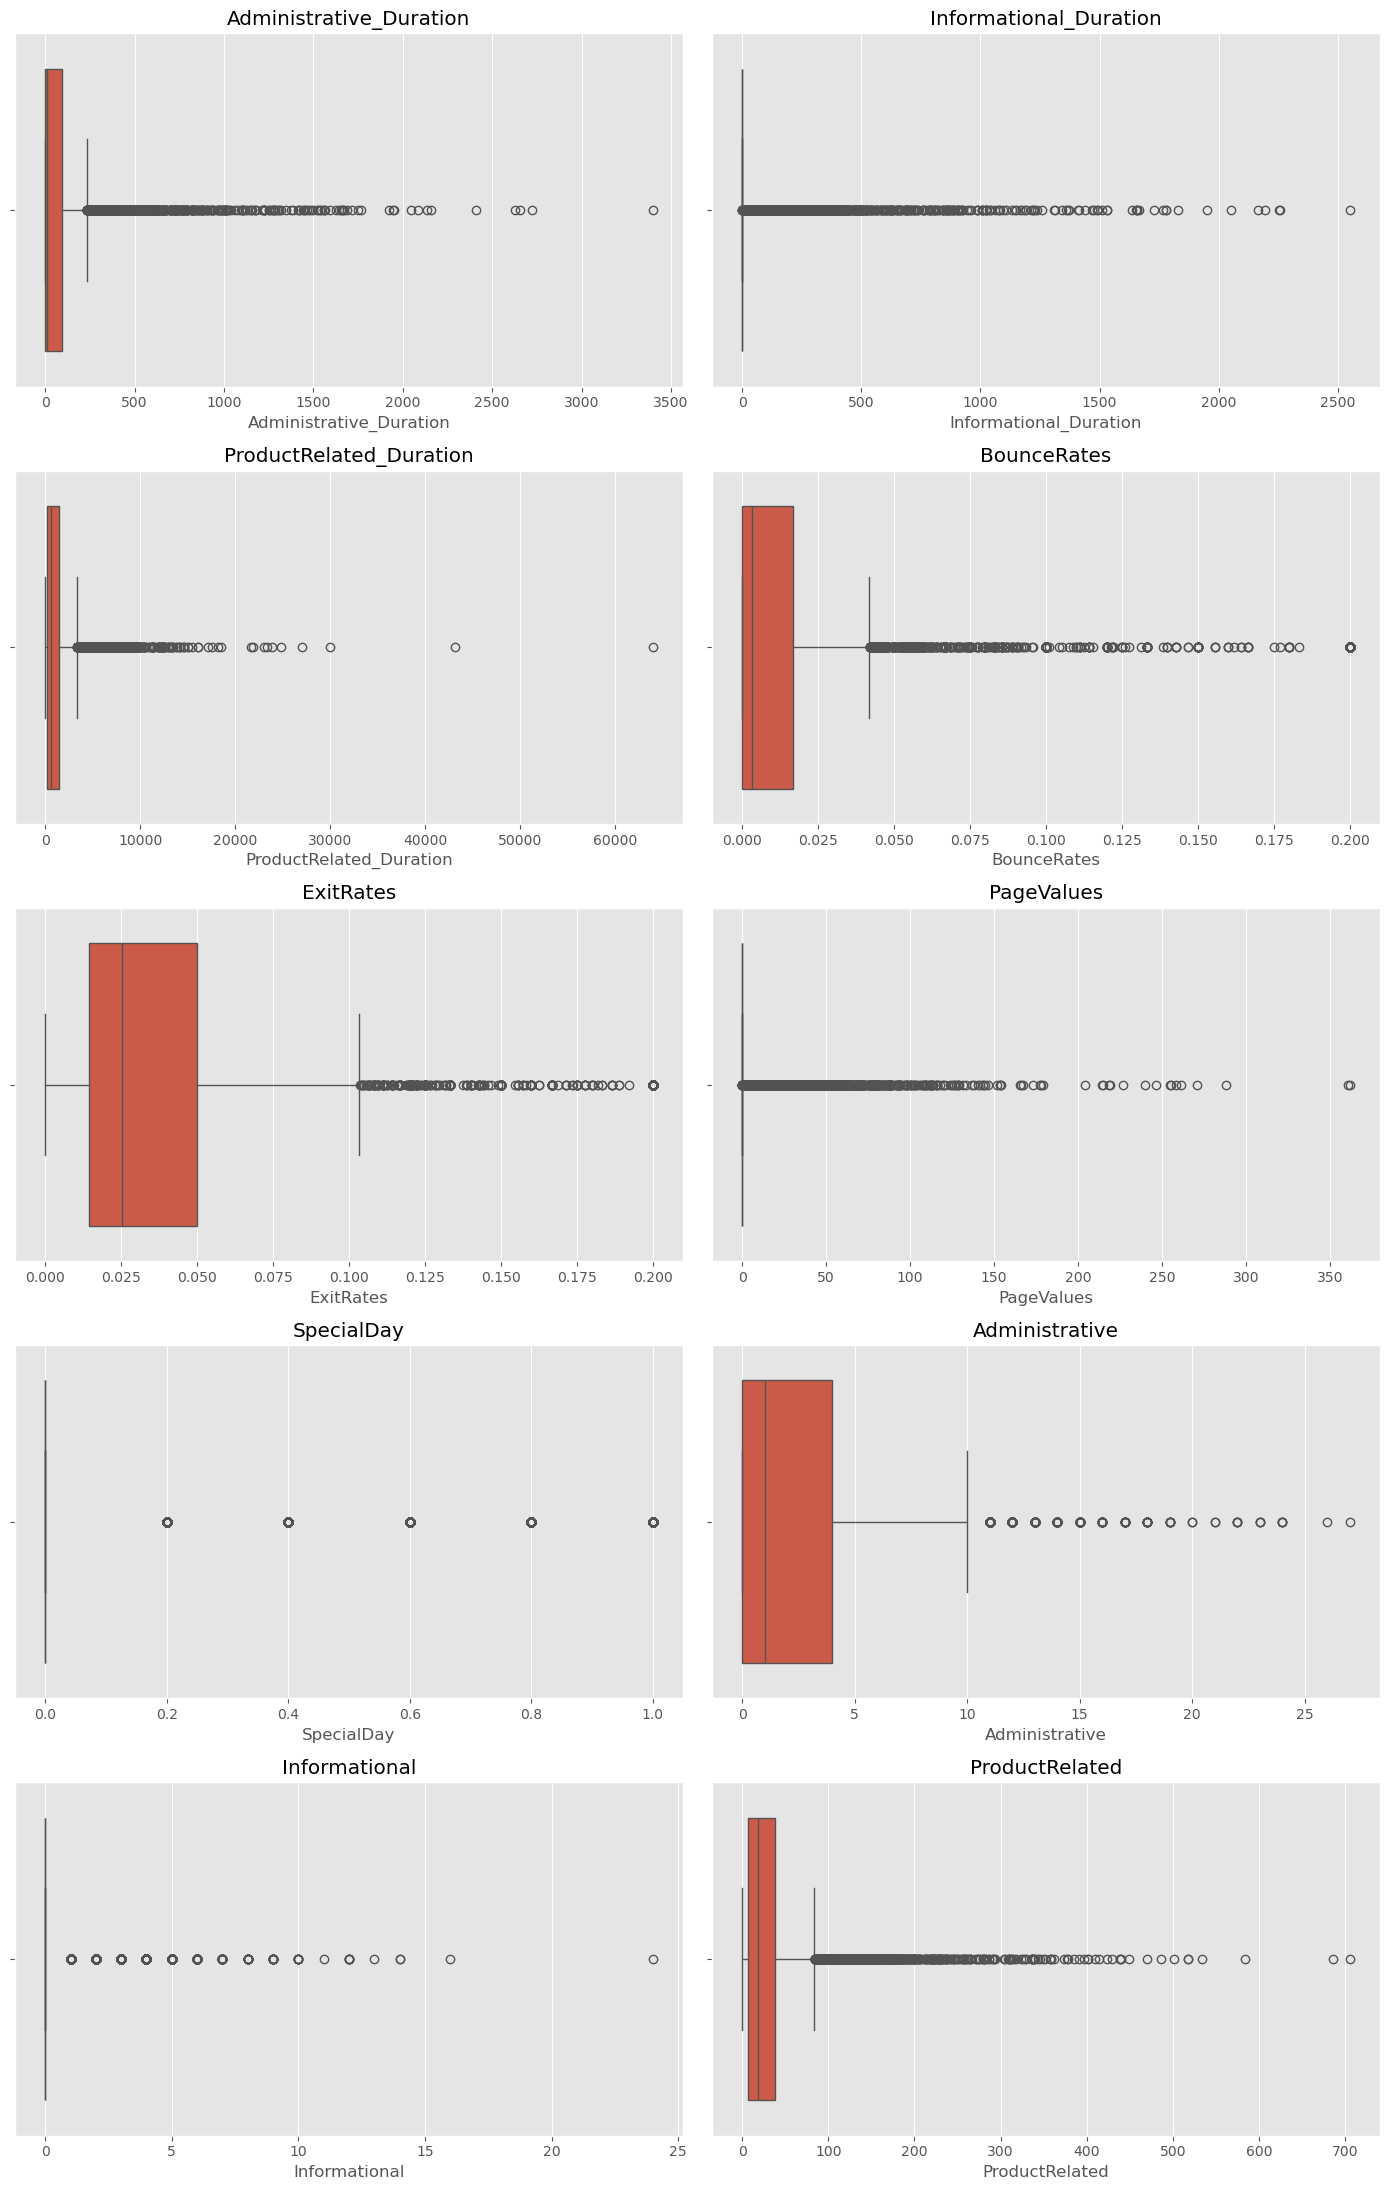

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [14]:
summary = pd.DataFrame({
    "Mean": df[num_features].mean(),
    "Median": df[num_features].median(),
    "Std": df[num_features].std(),
    "Min": df[num_features].min(),
    "Max": df[num_features].max(),
    "Skewness": df[num_features].skew()
})

summary.sort_values(
    by="Skewness",
    ascending=False
)

,Mean,Median,Std,Min,Max,Skewness
Informational_Duration,34.472398,0.000000,140.749294,0.0,2549.375000,7.579185
ProductRelated_Duration,1194.746220,598.936905,1913.669288,0.0,63973.522230,7.263228
PageValues,5.889258,0.000000,18.568437,0.0,361.763742,6.382964
Administrative_Duration,80.818611,7.500000,176.779107,0.0,3398.750000,5.615719
ProductRelated,31.731468,18.000000,44.475503,0.0,705.000000,4.341516
Informational,0.503569,0.000000,1.270156,0.0,24.000000,4.036464
SpecialDay,0.061427,0.000000,0.198917,0.0,1.000000,3.302667
BounceRates,0.022191,0.003112,0.048488,0.0,0.200000,2.947855
ExitRates,0.043073,0.025156,0.048597,0.0,0.200000,2.148789
Administrative,2.315166,1.000000,3.321784,0.0,27.000000,1.960357


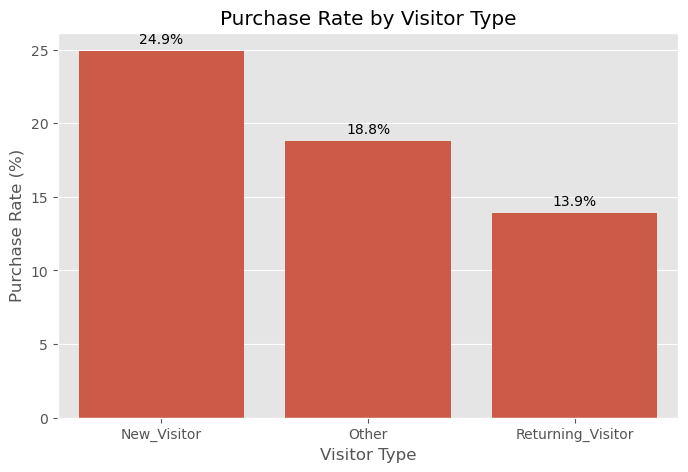

In [15]:
plt.figure(figsize=(8,5))

purchase_rate = (
    df.groupby("VisitorType")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

ax = sns.barplot(
    x=purchase_rate.index,
    y=purchase_rate.values
)

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")

for i, v in enumerate(purchase_rate.values):
    ax.text(i, v+0.5, f"{v:.1f}%", ha="center")

plt.show()

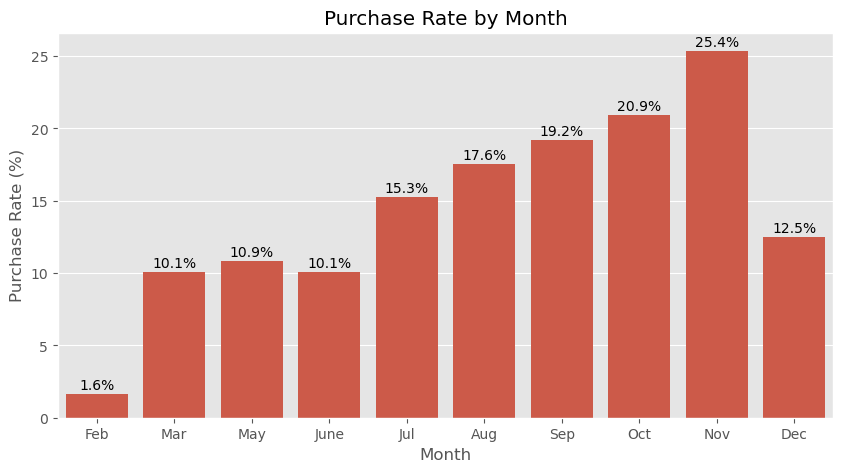

In [16]:
month_order = [
    "Feb","Mar","May","June","Jul",
    "Aug","Sep","Oct","Nov","Dec"
]

purchase_month = (
    df.groupby("Month")["Revenue"]
      .mean()
      *100
)

purchase_month = purchase_month.reindex(month_order)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=purchase_month.index,
    y=purchase_month.values
)

plt.title("Purchase Rate by Month")
plt.ylabel("Purchase Rate (%)")

for i, v in enumerate(purchase_month.values):
    if pd.notna(v):
        ax.text(i, v+0.3, f"{v:.1f}%", ha="center")

plt.show()

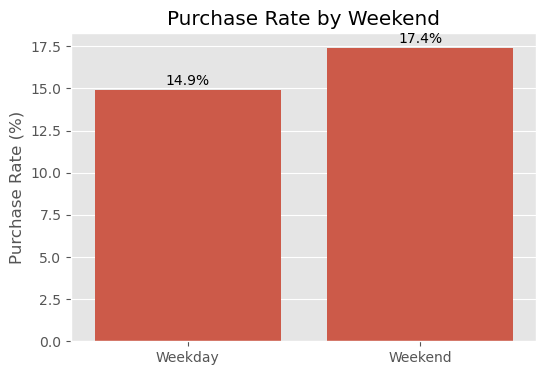

In [17]:
weekend_purchase = (
    df.groupby("Weekend")["Revenue"]
      .mean()
      *100
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=["Weekday","Weekend"],
    y=weekend_purchase.values
)

plt.ylabel("Purchase Rate (%)")
plt.title("Purchase Rate by Weekend")

for i, v in enumerate(weekend_purchase.values):
    ax.text(i, v+0.3, f"{v:.1f}%", ha="center")

plt.show()

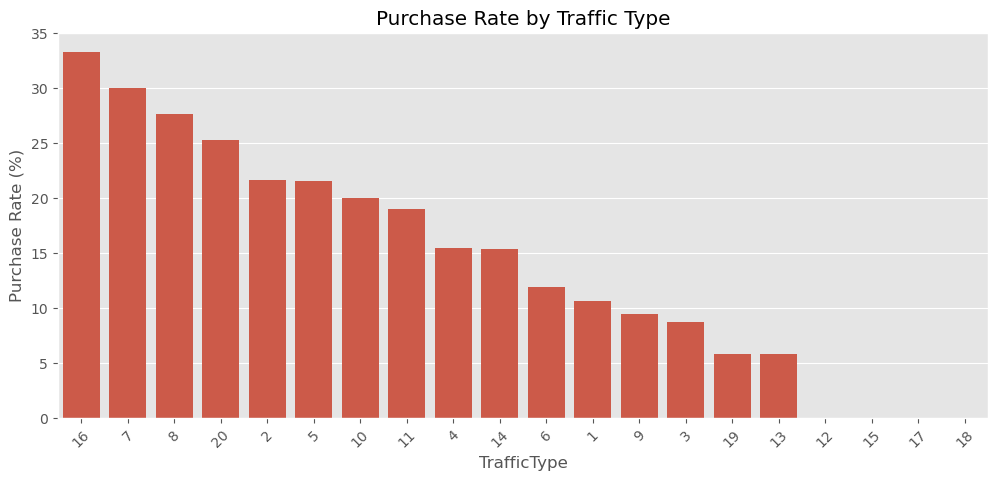

In [18]:
traffic = (
    df.groupby("TrafficType")["Revenue"]
      .mean()
      *100
)

traffic = traffic.sort_values(ascending=False)

plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=traffic.index.astype(str),
    y=traffic.values
)

plt.xticks(rotation=45)

plt.ylabel("Purchase Rate (%)")
plt.title("Purchase Rate by Traffic Type")

plt.show()

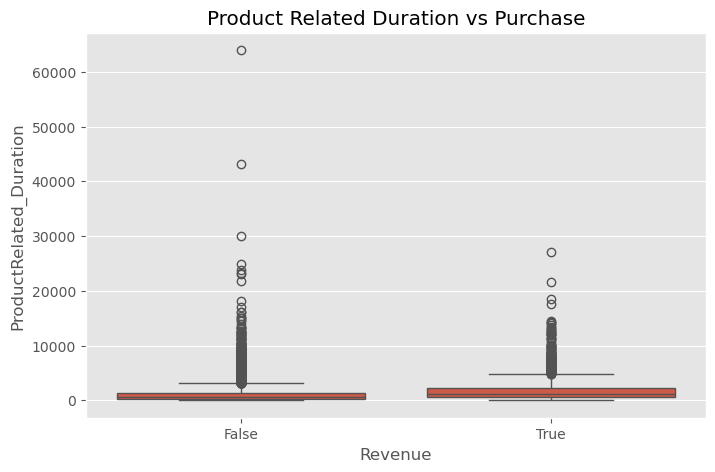

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="ProductRelated_Duration",
    data=df
)

plt.title("Product Related Duration vs Purchase")

plt.show()

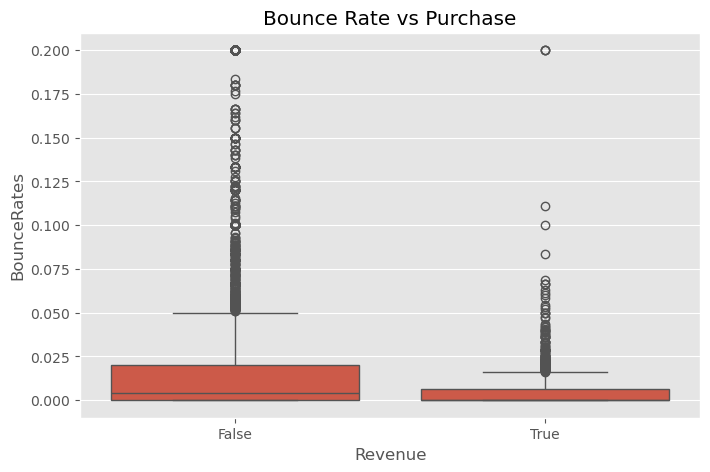

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="BounceRates",
    data=df
)

plt.title("Bounce Rate vs Purchase")

plt.show()

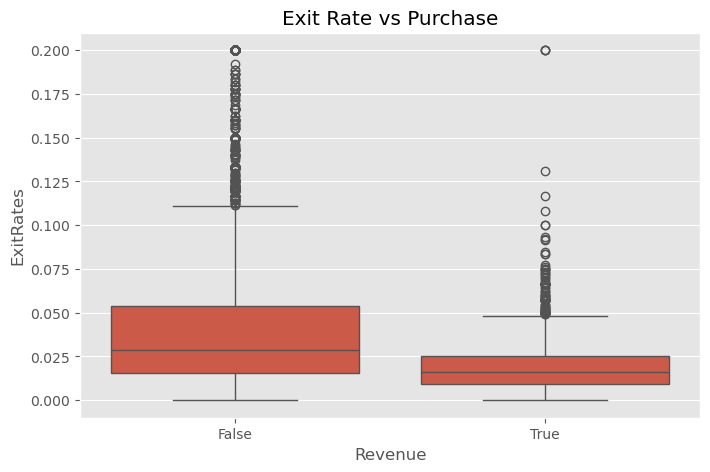

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="ExitRates",
    data=df
)

plt.title("Exit Rate vs Purchase")

plt.show()

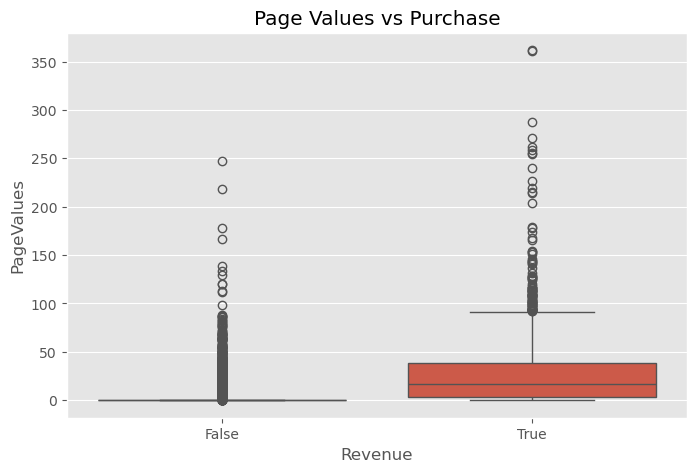

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="PageValues",
    data=df
)

plt.title("Page Values vs Purchase")

plt.show()

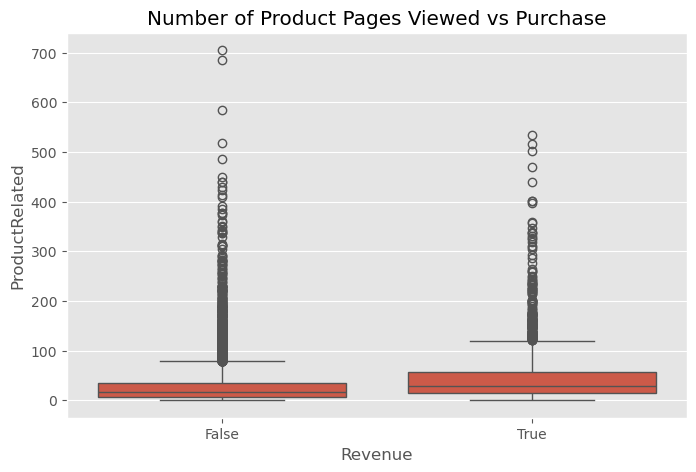

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Revenue",
    y="ProductRelated",
    data=df
)

plt.title("Number of Product Pages Viewed vs Purchase")

plt.show()

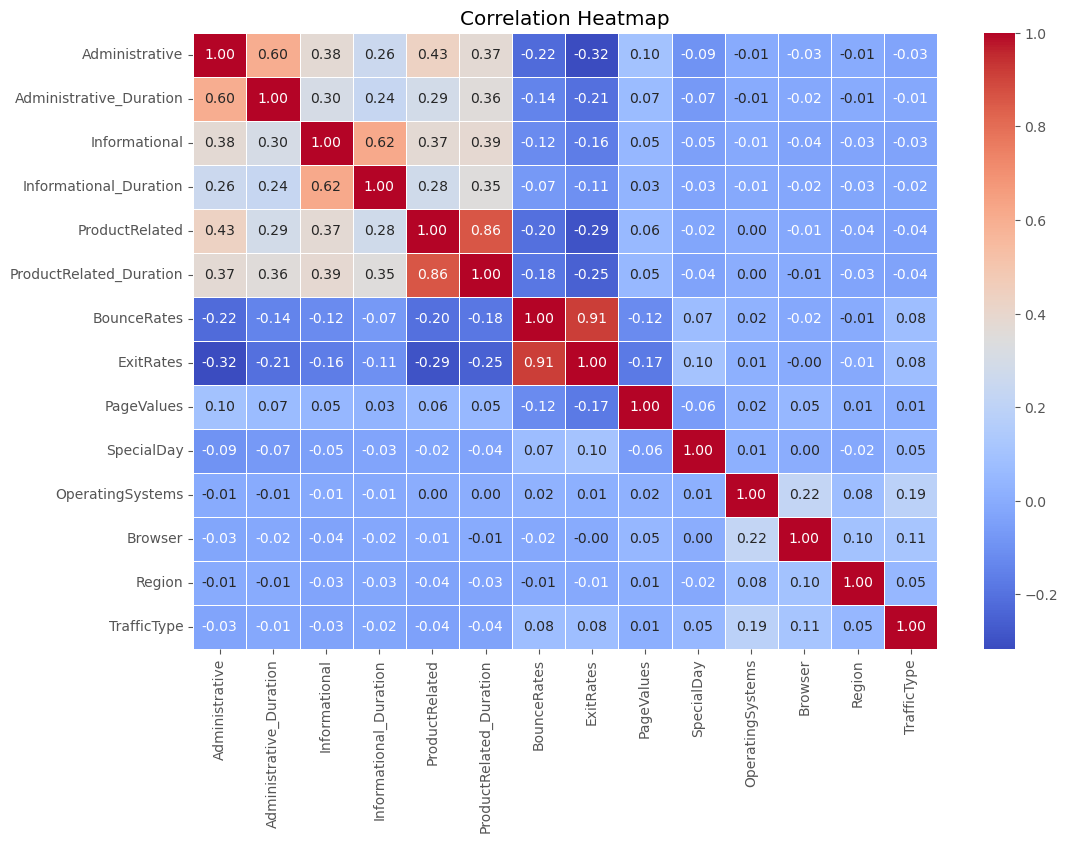

In [24]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
# Create a working copy
df_fe = df.copy()


In [26]:
df_fe["TotalBrowsingTime"] = (
    df_fe["Administrative_Duration"]
    + df_fe["Informational_Duration"]
    + df_fe["ProductRelated_Duration"]
)

In [27]:
df_fe[[
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "TotalBrowsingTime"
]].head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,TotalBrowsingTime
0,0.0,0.0,0.000000,0.000000
1,0.0,0.0,64.000000,64.000000
2,0.0,0.0,0.000000,0.000000
3,0.0,0.0,2.666667,2.666667
4,0.0,0.0,627.500000,627.500000


In [28]:
df_fe["TotalPagesVisited"] = (
    df_fe["Administrative"]
    + df_fe["Informational"]
    + df_fe["ProductRelated"]
)

In [29]:
df_fe[[
    "Administrative",
    "Informational",
    "ProductRelated",
    "TotalPagesVisited"
]].head()

,Administrative,Informational,ProductRelated,TotalPagesVisited
0,0,0,1,1
1,0,0,2,2
2,0,0,1,1
3,0,0,2,2
4,0,0,10,10


In [30]:
df_fe["AvgProductPageTime"] = (
    df_fe["ProductRelated_Duration"] /
    (df_fe["ProductRelated"] + 1)
)

In [31]:
df_fe["ExitBounceRatio"] = (
    df_fe["ExitRates"] /
    (df_fe["BounceRates"] + 0.0001)
)

In [32]:
df_fe["ValuePerProduct"] = (
    df_fe["PageValues"] /
    (df_fe["ProductRelated"] + 1)
)

In [33]:
df_fe["ReturningVisitor"] = (
    df_fe["VisitorType"] == "Returning_Visitor"
).astype(int)

In [34]:
holiday_months = ["Nov", "Dec"]

df_fe["HolidaySeason"] = (
    df_fe["Month"].isin(holiday_months)
).astype(int)

In [35]:
new_features = [
    "TotalBrowsingTime",
    "TotalPagesVisited",
    "AvgProductPageTime",
    "ExitBounceRatio",
    "ValuePerProduct",
    "ReturningVisitor",
    "HolidaySeason"
]

df_fe[new_features].head()

,TotalBrowsingTime,TotalPagesVisited,AvgProductPageTime,ExitBounceRatio,ValuePerProduct,ReturningVisitor,HolidaySeason
0,0.000000,1,0.000000,0.999500,0.0,1,0
1,64.000000,2,21.333333,1000.000000,0.0,1,0
2,0.000000,1,0.000000,0.999500,0.0,1,0
3,2.666667,2,0.888889,2.794411,0.0,1,0
4,627.500000,10,57.045455,2.487562,0.0,1,0


In [36]:
df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalBrowsingTime,12330.0,1310.037228,2037.801702,0.0,222.000000,680.000000,1626.908333,69921.647230
TotalPagesVisited,12330.0,34.550203,46.514053,0.0,8.000000,20.000000,42.000000,746.000000
AvgProductPageTime,12330.0,34.334360,34.326527,0.0,16.052654,27.096667,42.700000,705.500000
ExitBounceRatio,12330.0,113.113071,201.799332,0.0,1.961234,5.280096,150.915660,2000.000000
ValuePerProduct,12330.0,0.290892,1.367041,0.0,0.000000,0.000000,0.000000,37.976448
ReturningVisitor,12330.0,0.855718,0.351390,0.0,1.000000,1.000000,1.000000,1.000000
HolidaySeason,12330.0,0.383212,0.486189,0.0,0.000000,0.000000,1.000000,1.000000


In [37]:
X = df_fe.drop("Revenue", axis=1)
y = df_fe["Revenue"]

# Data Cleaning

In [38]:
print("Original Shape:", df.shape)
print("Feature Engineered Shape:", df_fe.shape)

Original Shape: (12330, 18)
Feature Engineered Shape: (12330, 25)


In [39]:
missing_values = df_fe.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [40]:
print("Duplicate Rows:", df_fe.duplicated().sum())

Duplicate Rows: 125


In [41]:
df_fe = df_fe.drop_duplicates()

print("Shape After Removing Duplicates:", df_fe.shape)

Shape After Removing Duplicates: (12205, 25)


In [42]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [43]:
df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalBrowsingTime,12205.0,1323.454242,2043.871589,0.0,231.666667,690.958333,1643.958333,69921.647230
TotalPagesVisited,12205.0,34.893240,46.627336,0.0,9.000000,20.000000,42.000000,746.000000
AvgProductPageTime,12205.0,34.686003,34.324645,0.0,16.380172,27.289722,42.906250,705.500000
ExitBounceRatio,12205.0,114.261305,202.509298,0.0,1.984127,5.539264,153.846150,2000.000000
ValuePerProduct,12205.0,0.293871,1.373705,0.0,0.000000,0.000000,0.000000,37.976448
ReturningVisitor,12205.0,0.854650,0.352468,0.0,1.000000,1.000000,1.000000,1.000000
HolidaySeason,12205.0,0.384105,0.486403,0.0,0.000000,0.000000,1.000000,1.000000


# Train-Test Split

In [44]:
X = df_fe.drop("Revenue", axis=1)
y = df_fe["Revenue"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [46]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Set: (9764, 24)
Testing Set : (2441, 24)

Training Target Distribution:
Revenue
False    0.843712
True     0.156288
Name: proportion, dtype: float64

Testing Target Distribution:
Revenue
False    0.843507
True     0.156493
Name: proportion, dtype: float64


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [48]:
numerical_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',

    'TotalBrowsingTime',
    'TotalPagesVisited',
    'AvgProductPageTime',
    'ExitBounceRatio',
    'ValuePerProduct'
]

In [49]:
categorical_features = [
    'Month',
    'VisitorType',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

In [50]:
boolean_features = [
    'Weekend',
    'ReturningVisitor',
    'HolidaySeason'
]

In [51]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [52]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [53]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bool", "passthrough", boolean_features)
])

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [55]:
print("Training Shape:", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

Training Shape: (9764, 80)
Testing Shape : (2441, 80)


In [56]:
feature_names = preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))
print(feature_names[:20])

Total Features: 80
['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__SpecialDay' 'num__TotalBrowsingTime'
 'num__TotalPagesVisited' 'num__AvgProductPageTime' 'num__ExitBounceRatio'
 'num__ValuePerProduct' 'cat__Month_Aug' 'cat__Month_Dec' 'cat__Month_Feb'
 'cat__Month_Jul' 'cat__Month_June']


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [59]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42
    )
}

In [60]:
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train_processed, y_train)

    # Predictions
    y_pred = model.predict(X_test_processed)

    # Probability predictions
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

In [61]:
y_prob = model.decision_function(X_test_processed)
roc_auc = roc_auc_score(y_test, y_prob)

In [62]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.906596,0.754967,0.596859,0.666667,0.927037
1,HistGradientBoosting,0.903728,0.727554,0.615183,0.666667,0.930890
2,Decision Tree,0.858664,0.543943,0.599476,0.570361,0.753114
3,Extra Trees,0.891848,0.770642,0.439791,0.560000,0.912273
4,Logistic Regression,0.890209,0.774038,0.421466,0.545763,0.898333


In [63]:
results_df.style.background_gradient(
    cmap="Greens",
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.906596,0.754967,0.596859,0.666667,0.927037
1,HistGradientBoosting,0.903728,0.727554,0.615183,0.666667,0.930890
2,Decision Tree,0.858664,0.543943,0.599476,0.570361,0.753114
3,Extra Trees,0.891848,0.770642,0.439791,0.560000,0.912273
4,Logistic Regression,0.890209,0.774038,0.421466,0.545763,0.898333


In [64]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Baseline Model: {best_model_name}")

Best Baseline Model: Random Forest


In [65]:
best_model = models[best_model_name]

print(best_model)

RandomForestClassifier(random_state=42)


In [66]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

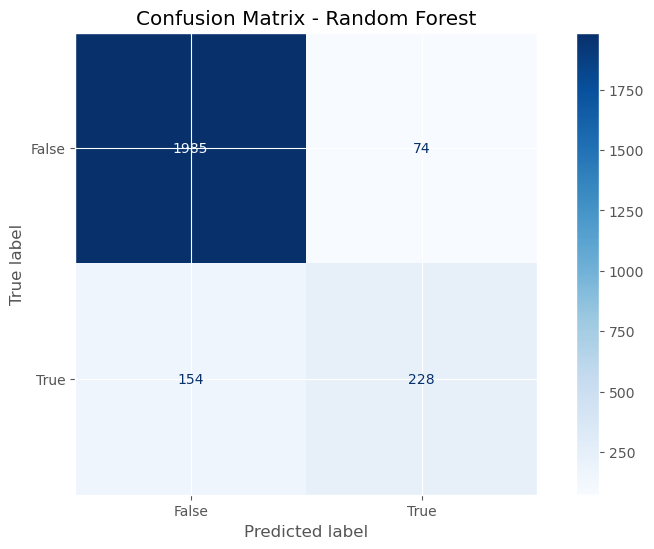

In [67]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_processed,
    y_test,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [68]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test_processed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.96      0.95      2059
        True       0.75      0.60      0.67       382

    accuracy                           0.91      2441
   macro avg       0.84      0.78      0.81      2441
weighted avg       0.90      0.91      0.90      2441



In [69]:
feature_names = preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))
feature_names[:20]

Total Features: 80


array(['num__Administrative', 'num__Administrative_Duration',
       'num__Informational', 'num__Informational_Duration',
       'num__ProductRelated', 'num__ProductRelated_Duration',
       'num__BounceRates', 'num__ExitRates', 'num__PageValues',
       'num__SpecialDay', 'num__TotalBrowsingTime',
       'num__TotalPagesVisited', 'num__AvgProductPageTime',
       'num__ExitBounceRatio', 'num__ValuePerProduct', 'cat__Month_Aug',
       'cat__Month_Dec', 'cat__Month_Feb', 'cat__Month_Jul',
       'cat__Month_June'], dtype=object)

In [70]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [71]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
14,num__ValuePerProduct,0.188755
8,num__PageValues,0.177956
7,num__ExitRates,0.052278
5,num__ProductRelated_Duration,0.049216
10,num__TotalBrowsingTime,0.046496
13,num__ExitBounceRatio,0.043580
12,num__AvgProductPageTime,0.042551
4,num__ProductRelated,0.041861
11,num__TotalPagesVisited,0.041483
1,num__Administrative_Duration,0.036272


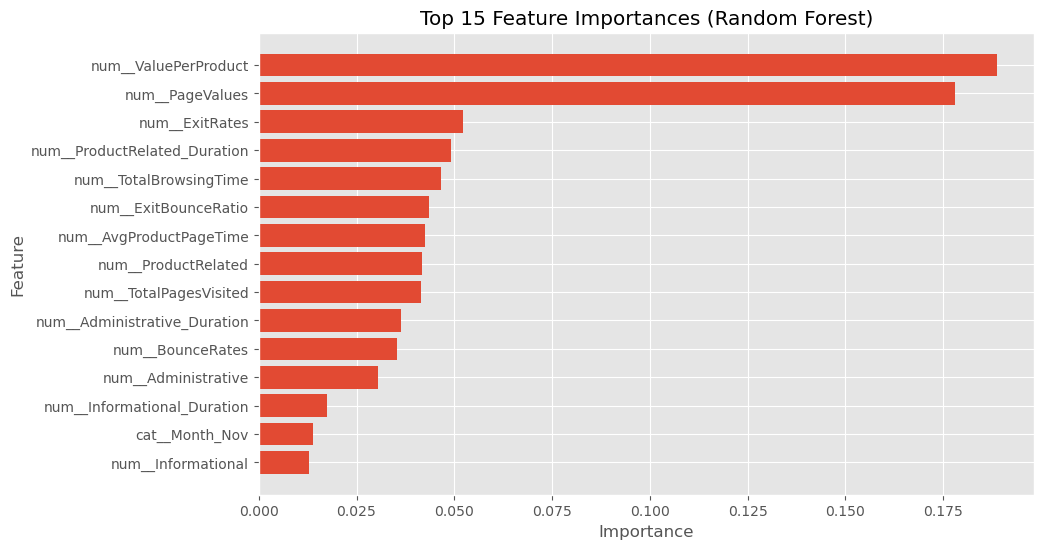

In [72]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Feature Importances ({best_model_name})")

plt.gca().invert_yaxis()

plt.show()

In [73]:
engineered = [
    "num__TotalBrowsingTime",
    "num__TotalPagesVisited",
    "num__AvgProductPageTime",
    "num__ExitBounceRatio",
    "num__ValuePerProduct",
    "bool__ReturningVisitor",
    "bool__HolidaySeason"
]

importance_df[
    importance_df["Feature"].isin(engineered)
]


,Feature,Importance
14,num__ValuePerProduct,0.188755
10,num__TotalBrowsingTime,0.046496
13,num__ExitBounceRatio,0.043580
12,num__AvgProductPageTime,0.042551
11,num__TotalPagesVisited,0.041483
79,bool__HolidaySeason,0.008885
78,bool__ReturningVisitor,0.003831


In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [75]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

# Compare Original vs Engineered Features

In [76]:
X_original = df.drop("Revenue", axis=1)
y_original = df["Revenue"]

In [77]:
baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
}

In [78]:
engineered_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
}

In [79]:
comparison = pd.DataFrame({
    "Original Features": baseline_results,
    "Engineered Features": engineered_results
})

comparison

,Original Features,Engineered Features
Accuracy,0.906596,0.906596
Precision,0.754967,0.754967
Recall,0.596859,0.596859
F1,0.666667,0.666667
ROC_AUC,0.930890,0.930890


#Hyperparameter Tuning

In [80]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1')

In [82]:
print(random_search.best_params_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [83]:
print(random_search.best_score_)

0.6467498364591436


In [84]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test_processed)
y_prob = best_rf.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2059
        True       0.74      0.59      0.66       382

    accuracy                           0.90      2441
   macro avg       0.84      0.78      0.80      2441
weighted avg       0.90      0.90      0.90      2441

ROC-AUC: 0.9295189806468347


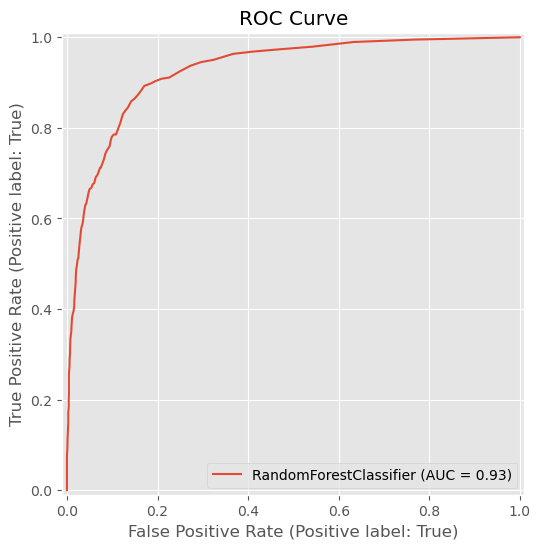

In [85]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test_processed,
    y_test
)

plt.title("ROC Curve")
plt.show()

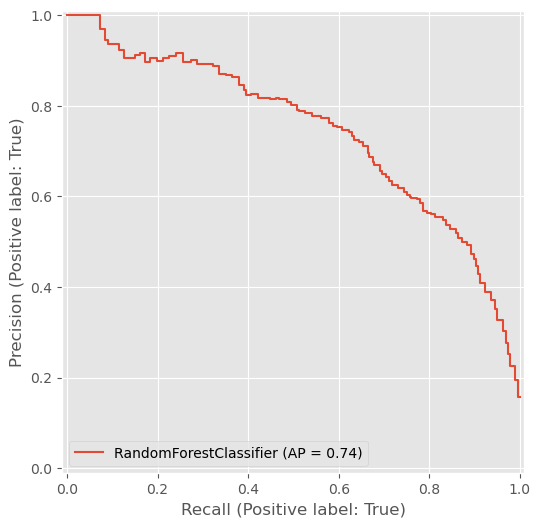

In [86]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test_processed,
    y_test
)

plt.show()

In [87]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.64285714 0.6716141  0.62146893 0.6368932  0.61940299]
0.6384472717108932


In [89]:
import shap

ModuleNotFoundError: No module named 'shap'

In [90]:
import joblib

joblib.dump(best_model, "models/best_model.pkl")

joblib.dump(preprocessor, "models/preprocessor.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/best_model.pkl'

In [91]:
import os

os.makedirs("models", exist_ok=True)

In [92]:
import joblib

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

['models/preprocessor.pkl']